# HCL Tech - Hackathon

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/kaggel_weather_2013_to_2024.csv')
df.shape

(3557, 29)

In [9]:
import pandas as pd

# Load CSV file
df = pd.read_csv("/content/drive/MyDrive/kaggel_weather_2013_to_2024.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             3557 non-null   int64  
 1   DATE                   3557 non-null   object 
 2   tempmax                3557 non-null   float64
 3   tempmin                3557 non-null   float64
 4   temp                   3557 non-null   float64
 5   feelslikemax           3557 non-null   float64
 6   feelslikemin           3557 non-null   float64
 7   feelslike              3557 non-null   float64
 8   humidity               3557 non-null   float64
 9   precip                 3557 non-null   float64
 10  precipprob             3557 non-null   int64  
 11  precipcover            3557 non-null   float64
 12  windspeed              3557 non-null   float64
 13  sealevelpressure       3557 non-null   float64
 14  conditions             3557 non-null   object 
 15  Year

In [10]:
import pandas as pd
import sqlite3

# Load your CSV file
df = pd.read_csv("/content/drive/MyDrive/kaggel_weather_2013_to_2024.csv")

# Create/connect to database
conn = sqlite3.connect("climate.db")

# Write data into database table
df.to_sql("delhi_climate", conn, if_exists="replace", index=False)

conn.close()

print("CSV successfully loaded into SQLite database!")


CSV successfully loaded into SQLite database!


In [11]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/kaggel_weather_2013_to_2024.csv")
print(df.columns)


Index(['Unnamed: 0', 'DATE', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'humidity', 'precip', 'precipprob',
       'precipcover', 'windspeed', 'sealevelpressure', 'conditions', 'Year',
       'month', 'dayofweek', 'dayofyear', 'year-2000', 'weekofyear',
       'tempmax_humidity', 'tempmin_humidity', 'temp_humidity',
       'feelslikemax_humidity', 'feelslikemin_humidity', 'feelslike_humidity',
       'temp_range', 'heat_index'],
      dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             3557 non-null   int64  
 1   DATE                   3557 non-null   object 
 2   tempmax                3557 non-null   float64
 3   tempmin                3557 non-null   float64
 4   temp                   3557 non-null   float64
 5   feelslikemax           3557 non-null   float64
 6   feelslikemin           3557 non-null   float64
 7   feelslike              3557 non-null   float64
 8   humidity               3557 non-null   float64
 9   precip                 3557 non-null   float64
 10  precipprob             3557 non-null   int64  
 11  precipcover            3557 non-null   float64
 12  windspeed              3557 non-null   float64
 13  sealevelpressure       3557 non-null   float64
 14  conditions             3557 non-null   object 
 15  Year

In [13]:
print(f"\nMissing Values:\n{df.isnull().sum()}")


Missing Values:
Unnamed: 0               0
DATE                     0
tempmax                  0
tempmin                  0
temp                     0
feelslikemax             0
feelslikemin             0
feelslike                0
humidity                 0
precip                   0
precipprob               0
precipcover              0
windspeed                0
sealevelpressure         0
conditions               0
Year                     0
month                    0
dayofweek                0
dayofyear                0
year-2000                0
weekofyear               0
tempmax_humidity         0
tempmin_humidity         0
temp_humidity            0
feelslikemax_humidity    0
feelslikemin_humidity    0
feelslike_humidity       0
temp_range               0
heat_index               0
dtype: int64


# preposessing

In [14]:
import sqlite3
import pandas as pd

# Make table output readable
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

# Connect to DB
conn = sqlite3.connect("climate.db")

# Load table
df = pd.read_sql("SELECT * FROM delhi_climate", conn)

conn.close()

print("\n=== RAW DATA LOADED FROM DB ===\n")
print(df.head())
print("\nShape:", df.shape)



=== RAW DATA LOADED FROM DB ===

   Unnamed: 0       DATE  tempmax  tempmin  temp  feelslikemax  feelslikemin  feelslike  humidity  precip  precipprob  precipcover  windspeed  sealevelpressure              conditions  Year  month  dayofweek  dayofyear  year-2000  weekofyear  tempmax_humidity  tempmin_humidity  temp_humidity  feelslikemax_humidity  feelslikemin_humidity  feelslike_humidity  temp_range  heat_index
0           0  4/14/2013     37.7     23.1  28.7          35.4          23.1       28.1      39.7     2.0         100         4.17       22.3            1008.3  Rain, Partially cloudy  2013      4          6        104         13          15           1496.69            917.07        1139.39                1405.38                 917.07             1115.57        14.6  147.178118
1           1  4/15/2013     37.5     21.1  28.6          35.3          21.1       28.0      41.7     0.0           0         0.00       17.6            1005.1                   Clear  2013      4    

In [17]:
print("\n=== DATA PREPROCESSING ===")

# 1. Convert DATE column to datetime
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')   # Convert properly
df['date'] = df['DATE']                                     # Use single datetime column

# 2. Filter years (2020–2024) using ONLY 'date'
df = df[(df['date'].dt.year >= 2020) & (df['date'].dt.year <= 2024)]
print(f"Data after filtering (2020-2024): {df.shape}")

# 3. Create new features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df['season'] = df['month'].apply(
    lambda x: 'Winter' if x in [12,1,2]
    else 'Summer' if x in [3,4,5]
    else 'Monsoon' if x in [6,7,8,9]
    else 'Autumn'
)

df['temp_range'] = df['tempmax'] - df['tempmin']

# Heat index function
def calculate_heat_index(temp, humidity):
    return temp + 0.5 * (humidity / 100) * (temp - 20)

df['heat_index'] = calculate_heat_index(df['temp'], df['humidity'])

print("\n=== SAMPLE OF PROCESSED DATA ===")
print(df[['date', 'temp', 'humidity', 'windspeed', 'sealevelpressure', 'heat_index']].head())



=== DATA PREPROCESSING ===
Data after filtering (2020-2024): (1795, 30)

=== SAMPLE OF PROCESSED DATA ===
           date  temp  humidity  windspeed  sealevelpressure  heat_index
1762 2020-01-01  11.1      80.8       14.8            1021.0     7.50440
1763 2020-01-02  13.9      76.2        9.4            1020.8    11.57590
1764 2020-01-03  15.3      77.3       13.0            1018.3    13.48345
1765 2020-01-04  14.3      77.9       14.8            1017.5    12.07985
1766 2020-01-05  14.2      73.0       16.6            1017.9    12.08300


In [39]:
print("\n=== ADVANCED DATA PREPROCESSING MODULE ===")

# ---------------------------------------------
# 1️⃣ HANDLE MISSING VALUES
# ---------------------------------------------
print("\nMissing values BEFORE cleaning:")
print(df.isna().sum())

# Numeric columns → interpolate
df = df.interpolate(method='linear')

# Categorical → forward/backward fill
df = df.fillna(method='ffill').fillna(method='bfill')

print("\nMissing values AFTER cleaning:")
print(df.isna().sum())


# ---------------------------------------------
# 2️⃣ OUTLIER DETECTION & FIXING
# (Using 1%–99% percentile clipping)
# ---------------------------------------------
import numpy as np

numeric_cols = df.select_dtypes(include=['float64','int64']).columns

for col in numeric_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

print("\nOutliers clipped using percentile method.")


# ---------------------------------------------
# 3️⃣ STATIONARITY CHECK (ADF Test)
# ---------------------------------------------
from statsmodels.tsa.stattools import adfuller

print("\n=== ADF STATIONARITY TEST RESULTS ===")

stationary_cols = []
non_stationary_cols = []

for col in numeric_cols:
    try:
        p_value = adfuller(df[col].dropna())[1]
        print(f"{col}: p-value = {p_value:.5f}")

        if p_value <= 0.05:
            stationary_cols.append(col)
        else:
            non_stationary_cols.append(col)
    except:
        pass

print("\nStationary Features:", stationary_cols)
print("Non-Stationary Features:", non_stationary_cols)


# ---------------------------------------------
# 4️⃣ APPLY TRANSFORMATION IF NEEDED
# ---------------------------------------------
for col in non_stationary_cols:
    df[col + "_diff"] = df[col].diff()

df = df.dropna()  # remove diff NA rows

print("\nApplied differencing to non-stationary features.")


# ---------------------------------------------
# 5️⃣ NORMALIZATION / SCALING (MinMaxScaler)
# ---------------------------------------------
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nScaling completed. Data is now model-ready.")


print("\n=== FINAL PREPROCESSED DATA SAMPLE ===")
print(df.head())



=== ADVANCED DATA PREPROCESSING MODULE ===

Missing values BEFORE cleaning:
Unnamed: 0                   0
DATE                         0
tempmax                      0
tempmin                      0
temp                         0
feelslikemax                 0
feelslikemin                 0
feelslike                    0
humidity                     0
precip                       0
precipprob                   0
precipcover                  0
windspeed                    0
sealevelpressure             0
conditions                   0
Year                         0
month                        0
dayofweek                    0
dayofyear                    0
year-2000                    0
weekofyear                   0
tempmax_humidity             0
tempmin_humidity             0
temp_humidity                0
feelslikemax_humidity        0
feelslikemin_humidity        0
feelslike_humidity           0
temp_range                   0
heat_index                   0
date                    

In [19]:
print("\n=== FEATURE ENGINEERING STARTED ===")

# If DATE is already the index → convert index to datetime
df.index = pd.to_datetime(df.index)

# -----------------------------
# 1️⃣ TIME-BASED FEATURES
# -----------------------------
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['weekday'] = df.index.weekday
df['dayofyear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)

print("Time-based features created.")

# -----------------------------
# 2️⃣ SEASON FEATURE
# -----------------------------
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

df['season'] = df['month'].apply(get_season)
print("Season feature created.")

# -----------------------------
# 3️⃣ HOLIDAY INDICATOR
# -----------------------------
import pandas as pd

holidays = pd.to_datetime([
    "2020-01-01", "2020-08-15", "2020-10-02",
    "2021-01-01", "2021-08-15", "2021-10-02",
    "2022-01-01", "2022-08-15", "2022-10-02",
    "2023-01-01", "2023-08-15", "2023-10-02",
    "2024-01-01", "2024-08-15", "2024-10-02"
])

df['is_holiday'] = df.index.isin(holidays).astype(int)

print("Holiday feature added.")

# -----------------------------
# 4️⃣ INTERACTION FEATURES
# -----------------------------
df['temp_range'] = df['tempmax'] - df['tempmin']
df['humidity_temp_interaction'] = df['humidity'] * df['temp']
df['wind_temp_interaction'] = df['windspeed'] * df['temp']

print("Interaction features created.")

# -----------------------------
# 5️⃣ CORRELATION ANALYSIS
# -----------------------------
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

print("\n=== CORRELATION WITH TEMPERATURE ===")
corr_temp = df[numeric_cols].corr()['temp'].sort_values(ascending=False)
print(corr_temp)

top_features = corr_temp.abs().sort_values(ascending=False).head(10).index.tolist()
print("\nTop 10 Selected Features:", top_features)

df_selected = df[top_features]

print("\n=== SAMPLE OF SELECTED FEATURES ===")
print(df_selected.head())

print("\n=== FEATURE ENGINEERING COMPLETED ===")



=== FEATURE ENGINEERING STARTED ===
Time-based features created.
Season feature created.
Holiday feature added.
Interaction features created.

=== CORRELATION WITH TEMPERATURE ===
temp                         1.000000
heat_index                   0.994726
tempmax                      0.969946
tempmin                      0.964769
feelslike                    0.950702
feelslikemax                 0.939497
feelslikemin                 0.930111
wind_temp_interaction        0.702025
feelslikemin_humidity        0.544507
tempmin_humidity             0.519810
feelslike_humidity           0.480981
humidity_temp_interaction    0.478306
temp_humidity                0.463181
feelslikemax_humidity        0.388215
windspeed                    0.332814
tempmax_humidity             0.316432
Unnamed: 0_diff              0.179383
precipprob                   0.166491
tempmin_diff                 0.089536
temp_diff                    0.088047
heat_index_diff              0.087726
feelslike_diff       

# Exploratory Data Analysis

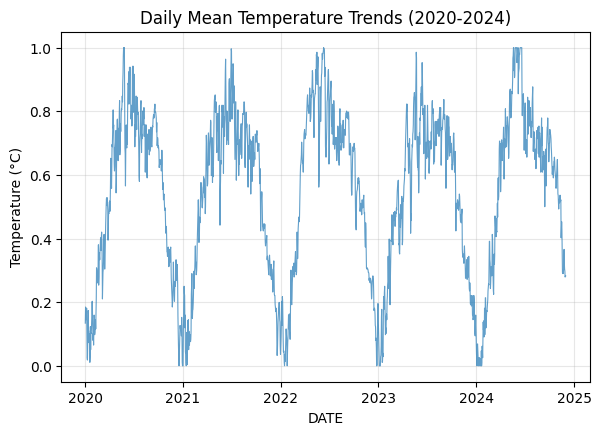

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(15, 10))

# Plot 1: Temperature trends over time
plt.subplot(2, 2, 1)
plt.plot(df['date'], df['temp'], alpha=0.7, linewidth=0.8)
plt.title('Daily Mean Temperature Trends (2020-2024)')
plt.xlabel('DATE')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Winter'),
  Text(1, 0, 'Summer'),
  Text(2, 0, 'Monsoon'),
  Text(3, 0, 'Autumn')])

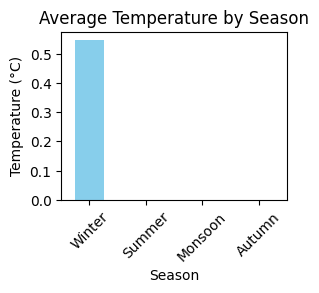

In [21]:

# Plot 2: Seasonal temperature distribution
plt.subplot(2, 2, 2)
seasonal_avg = df.groupby('season')['temp'].mean().reindex(['Winter',
                                            'Summer', 'Monsoon', 'Autumn'])
seasonal_avg.plot(kind='bar', color=['skyblue', 'coral', 'lightgreen', 'gold'])
plt.title('Average Temperature by Season')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)

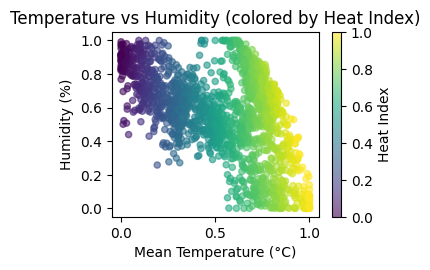

In [40]:
# Plot 3: Humidity vs Temperature scatter
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['humidity'], alpha=0.6, c=df['heat_index'],
           cmap='viridis', s=20)
plt.colorbar(label='Heat Index')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs Humidity (colored by Heat Index)')

plt.tight_layout()
plt.show()


===  EXPLORATORY DATA ANALYSIS (EDA) ===

=== DISTRIBUTION PLOTS ===


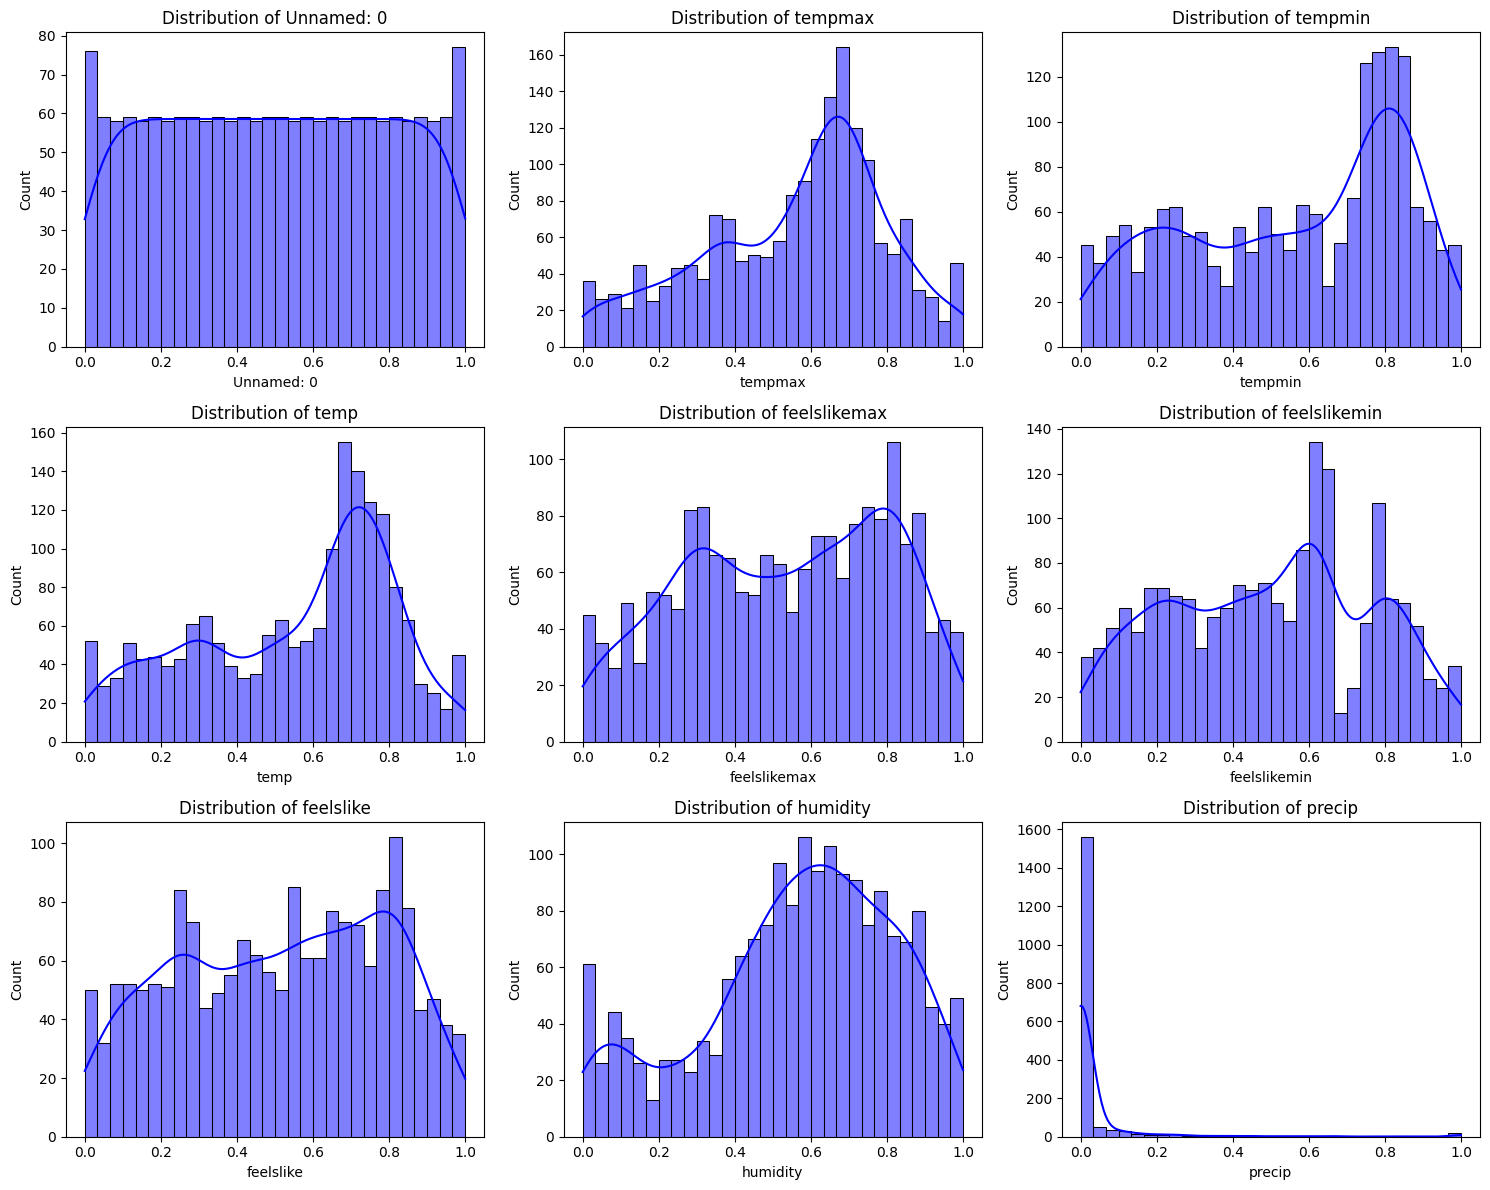


=== CORRELATION HEATMAP ===


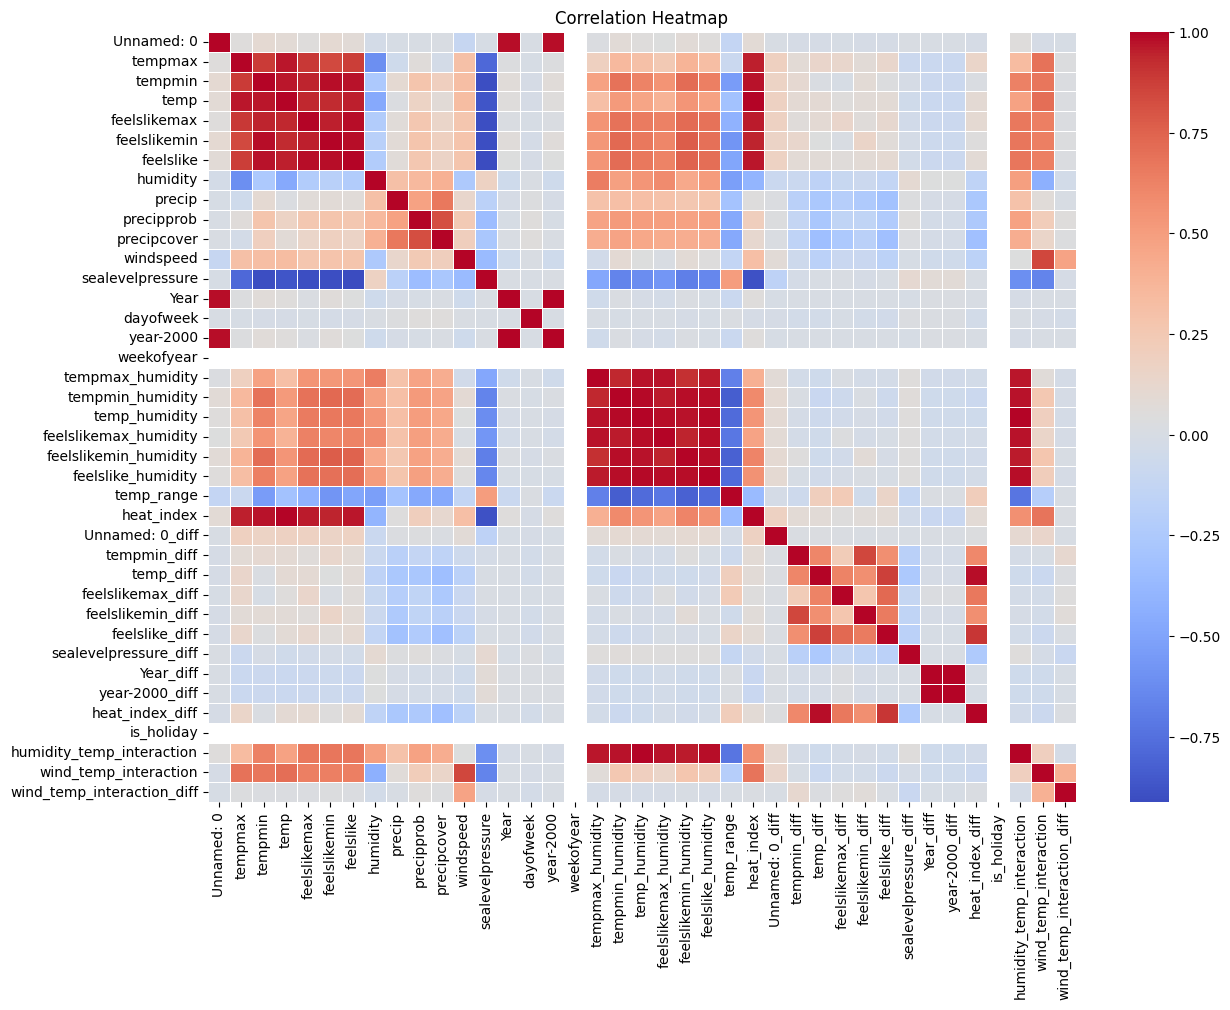


=== SKEWNESS OF NUMERIC FEATURES ===
Unnamed: 0                    -0.000117
tempmax                       -0.480557
tempmin                       -0.383313
temp                          -0.468251
feelslikemax                  -0.185857
feelslikemin                  -0.050158
feelslike                     -0.141165
humidity                      -0.528870
precip                         5.362260
precipprob                     1.274504
precipcover                    2.637527
windspeed                      0.714278
sealevelpressure              -0.016572
Year                           0.022294
dayofweek                     -0.001746
year-2000                      0.022294
weekofyear                     0.000000
tempmax_humidity               0.218163
tempmin_humidity               0.513886
temp_humidity                  0.438958
feelslikemax_humidity          0.706352
feelslikemin_humidity          0.676584
feelslike_humidity             0.716796
temp_range                    -0.110350
he

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n===  EXPLORATORY DATA ANALYSIS (EDA) ===")

# Select numeric columns only
numeric_cols = df.select_dtypes(include=['float64','int64']).columns


# -------------------------------------------------------
# 1️⃣ DISTRIBUTION PLOTS
# -------------------------------------------------------
print("\n=== DISTRIBUTION PLOTS ===")

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols[:9]):   # show first 9 features
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


# -------------------------------------------------------
# 2️⃣ CORRELATION HEATMAP
# -------------------------------------------------------
print("\n=== CORRELATION HEATMAP ===")

plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()


# -------------------------------------------------------
# 3️⃣ SKEWNESS CHECK
# -------------------------------------------------------
print("\n=== SKEWNESS OF NUMERIC FEATURES ===")
skew_vals = df[numeric_cols].skew()
print(skew_vals)

# Highlight high skewness
high_skew = skew_vals[abs(skew_vals) > 1]
print("\nHighly Skewed Features (|skew| > 1):")
print(high_skew)


# -------------------------------------------------------
# 4️⃣ OUTLIER DETECTION (IQR METHOD)
# -------------------------------------------------------
print("\n=== OUTLIER DETECTION (IQR METHOD) ===")

def detect_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers)

for col in numeric_cols:
    count = detect_outliers(col)
    print(f"{col}: {count} outliers detected")

print("\n=== EDA COMPLETED ===")


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("\n=== REGRESSION ANALYSIS ===")
print("Task: Predict maximum temperature (tempmax) using other weather parameters")

features_reg = ['humidity', 'windspeed', 'sealevelpressure', 'tempmin',]
X_reg = df[features_reg]
y_reg = df['tempmax']

X_reg = X_reg.fillna(X_reg.mean())
y_reg = y_reg.fillna(y_reg.mean())

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg,
                                            test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


=== REGRESSION ANALYSIS ===
Task: Predict maximum temperature (tempmax) using other weather parameters
Training set size: 1434
Test set size: 359


In [24]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)


models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

print("\nRegression Results:")
print("-" * 60)


#  MODEL TRAINING + EVALUATION

for name, model in models.items():

    # Train & Predict
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-10))) * 100
    wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100

    # Save results
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'wMAPE': wmape,
        'R2': r2,
        'predictions': y_pred
    }

    # Display metrics
    print(f"{name:20} | RMSE: {rmse:8.3f} | R²: {r2:6.3f} | "
          f"MAE: {mae:8.3f} | MAPE: {mape:8.3f}% | wMAPE: {wmape:8.3f}%")



Regression Results:
------------------------------------------------------------
Linear Regression    | RMSE:    0.057 | R²:  0.942 | MAE:    0.043 | MAPE: 1830108417.931% | wMAPE:    7.691%
Random Forest        | RMSE:    0.054 | R²:  0.948 | MAE:    0.041 | MAPE: 698923701.398% | wMAPE:    7.324%


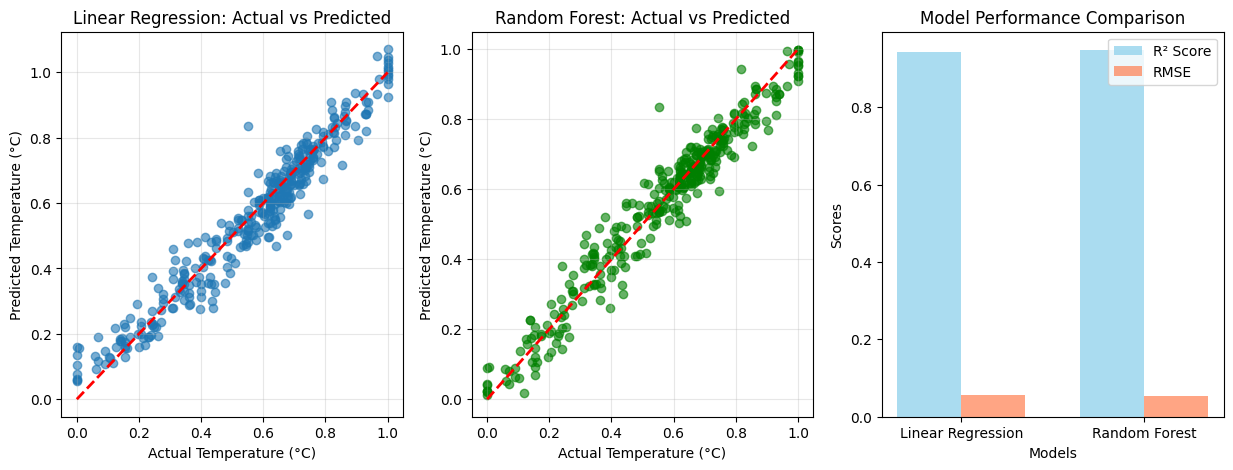

In [25]:
plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
plt.scatter(y_test, results['Linear Regression']['predictions'], alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Linear Regression: Actual vs Predicted')
plt.grid(True, alpha=0.3)


plt.subplot(1, 3, 2)
plt.scatter(y_test, results['Random Forest']['predictions'], alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Random Forest: Actual vs Predicted')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
models_list = list(results.keys())
r2_scores = [results[model]['R2'] for model in models_list]
rmse_scores = [results[model]['RMSE'] for model in models_list]


x = np.arange(len(models_list))
width = 0.35

bars1 = plt.bar(x - width/2, r2_scores, width, label='R² Score', color='skyblue', alpha=0.7)
bars2 = plt.bar(x + width/2, rmse_scores, width, label='RMSE', color='coral', alpha=0.7)

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, models_list)
plt.legend()


In [26]:
print("\n=== BASELINE MODEL (1-Month Naive Forecast) ===")

# Shift y_test by 30 days (1 month)
naive_pred = y_test.shift(30).fillna(method='bfill')

baseline_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
baseline_mae = mean_absolute_error(y_test, naive_pred)
baseline_mape = np.mean(np.abs((y_test - naive_pred) / (y_test + 1e-10))) * 100

print(f"Naive Forecast RMSE: {baseline_rmse:.3f}")
print(f"Naive Forecast MAE : {baseline_mae:.3f}")
print(f"Naive Forecast MAPE: {baseline_mape:.3f}%")



=== BASELINE MODEL (1-Month Naive Forecast) ===
Naive Forecast RMSE: 0.346
Naive Forecast MAE : 0.277
Naive Forecast MAPE: 11322218131.575%


In [28]:


import warnings
warnings.filterwarnings("ignore")

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reset index for forecasting models (important)
y_train_ar = y_train.reset_index(drop=True)
y_test_ar  = y_test.reset_index(drop=True)

# CLEAN Evaluation function (no return → no tuple printed)
def evaluate(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

    print(f"{model_name:15} | RMSE: {rmse:7.3f} | MAE: {mae:7.3f} | MAPE: {mape:7.3f}%")



In [29]:
from statsmodels.tsa.arima.model import ARIMA

print("=== ARIMA MODEL ===")

arima = ARIMA(y_train_ar, order=(5,1,2)).fit()
arima_pred = arima.forecast(len(y_test_ar))

evaluate(y_test_ar, arima_pred, "ARIMA")


=== ARIMA MODEL ===
ARIMA           | RMSE:   0.238 | MAE:   0.195 | MAPE: 10825053962.214%


In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("=== SARIMA MODEL ===")

sarima = SARIMAX(
    y_train_ar,
    order=(2,1,2),
    seasonal_order=(1,1,1,12)
).fit()

sarima_pred = sarima.forecast(len(y_test_ar))

evaluate(y_test_ar, sarima_pred, "SARIMA")


=== SARIMA MODEL ===
SARIMA          | RMSE:   0.238 | MAE:   0.195 | MAPE: 10750716361.427%


In [31]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("=== HOLT-WINTER MODEL ===")

hw = ExponentialSmoothing(
    y_train_ar,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

hw_pred = hw.forecast(len(y_test_ar))

evaluate(y_test_ar, hw_pred, "Holt-Winter")


=== HOLT-WINTER MODEL ===
Holt-Winter     | RMSE:   0.238 | MAE:   0.195 | MAPE: 10713203395.775%


In [32]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

print("=== ETS MODEL ===")

ets = ETSModel(
    y_train_ar,
    error="add",
    trend="add",
    seasonal=None
).fit()

ets_pred = ets.forecast(len(y_test_ar))

evaluate(y_test_ar, ets_pred, "ETS")


=== ETS MODEL ===
ETS             | RMSE:   0.239 | MAE:   0.196 | MAPE: 10742354222.824%


In [33]:
!pip install -q optuna
import optuna
import warnings
warnings.filterwarnings("ignore")


In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

def sarima_objective(trial):
    p = trial.suggest_int("p", 0, 3)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 3)

    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)


    s = 12

    try:
        model = SARIMAX(
            y_train_ar,
            order=(p, d, q),
            seasonal_order=(P, D, Q, s)
        ).fit(disp=False)

        pred = model.forecast(len(y_test_ar))
        rmse = np.sqrt(mean_squared_error(y_test_ar, pred))
        return rmse

    except:
        return float('inf')


print("=== Running SARIMA Hyperparameter Tuning (Optuna) ===")
study = optuna.create_study(direction="minimize")
study.optimize(sarima_objective, n_trials=30)

print("\nBest Parameters:", study.best_params)
print("Best RMSE:", study.best_value)


[I 2025-12-12 12:06:44,685] A new study created in memory with name: no-name-bde4e465-b717-413a-a0e1-1c1361e602b9


=== Running SARIMA Hyperparameter Tuning (Optuna) ===


[I 2025-12-12 12:07:03,476] Trial 0 finished with value: 0.47310634950376196 and parameters: {'p': 1, 'd': 2, 'q': 1, 'P': 0, 'D': 0, 'Q': 2}. Best is trial 0 with value: 0.47310634950376196.
[I 2025-12-12 12:07:41,098] Trial 1 finished with value: 0.23850776078220515 and parameters: {'p': 2, 'd': 2, 'q': 3, 'P': 2, 'D': 0, 'Q': 1}. Best is trial 1 with value: 0.23850776078220515.
[I 2025-12-12 12:07:48,695] Trial 2 finished with value: 0.38998570130753635 and parameters: {'p': 2, 'd': 2, 'q': 1, 'P': 0, 'D': 0, 'Q': 1}. Best is trial 1 with value: 0.23850776078220515.
[I 2025-12-12 12:08:11,849] Trial 3 finished with value: 0.23774207853888615 and parameters: {'p': 2, 'd': 0, 'q': 0, 'P': 0, 'D': 1, 'Q': 2}. Best is trial 3 with value: 0.23774207853888615.
[I 2025-12-12 12:08:13,495] Trial 4 finished with value: 0.3890362856959515 and parameters: {'p': 0, 'd': 2, 'q': 1, 'P': 1, 'D': 0, 'Q': 0}. Best is trial 3 with value: 0.23774207853888615.
[I 2025-12-12 12:08:28,550] Trial 5 finis


Best Parameters: {'p': 2, 'd': 0, 'q': 2, 'P': 1, 'D': 1, 'Q': 1}
Best RMSE: 0.23772027466474502


In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestRegressor()

grid = GridSearchCV(
    rf,
    param_grid=rf_params,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_rf = grid.best_estimator_


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 200}


In [38]:
rf_pred = best_rf.predict(X_test)
evaluate(y_test, rf_pred, "Tuned RandomForest")


Tuned RandomForest | RMSE:   0.053 | MAE:   0.041 | MAPE: 800323100.449%
